In [1]:
import math
from typing import Callable
import numpy as np

np.random.seed(2)

Un supermercado pequeño cuenta con $N$ cajas registradoras en servicio y con $S$ máquinas de repuesto, todas ellas de idéntica marca, modelo y antigüedad. Además el supermercado cuenta con los servicios de un técnico que repara las máquinas. El técnico repara las máquinas en serie, encargándose de una sola por vez. El fallo del sistema ocurre cuando se tienen menos de $N$ cajas en servicio, o lo que es lo mismo, se poseen más de $S$ cajas registradoras defectuosas en el taller. <br>
Todos los tiempos de funcionamiento de las cajas hasta descomponerse son variables independientes exponenciales con un tiempo medio hasta fallar de $T_F$ , y el tiempo de reparación de una caja que ingresa a taller es una variable exponencial con tiempo medio igual a $T_R$, independiente de todos los anteriores.


### Ejercicio 2. Problema de Reparación con dos operarios
El supermercado desea aumentar el tiempo medio del sistema y para esto analiza la posibilidad de contratar dos operarios, o bien comprar otra caja extra como repuesto. Para estudiar cual es la mejor alternativa, reconsidere el problema de reparación asumiendo que el taller tiene dos operarios igualmente idóneos que
trabajan en paralelo.

1. Escribir un programa para simular el modelo de reparación con dos colas.

2. Inicializar el programa con los tiempos de fallos de cada una las cajas en uso, y ejecutarlo para estimar el tiempo medio de fallo del sistema y su correspondiente desviación estándar. Utilizar nuevamente $N = 7, S = 3$ y que el tiempo medio de fallo de una caja es de un mes. Suponga nuevamente cada
operario del taller emplea un tiempo aleatorio con distribución exponencial de media igual a $1/8$ de mes para brindar servicio a una caja descompuesta.

3. Construir un histograma con los tiempos de fallo a partir de $10000$ simulaciones. Analizar las características del histograma.

4. Comparar los resultados con la situación en que se agregue una máquina de repuesto en lugar de agregar un operario. Realizar pruebas de bondad de ajuste para ambas situaciones.


In [2]:
import math
from typing import Callable

# Punto 1


def reparacion_1_operario(
    n: int,
    s: int,
    t_funcionamiento: Callable[[], float],
    t_reparacion_operario: Callable[[], float]
) -> float:

    # Inicialización
    t, r = 0, 0

    # Arreglo de tiempos de funcionamiento de las cajas registradoras
    T = []
    for _ in range(n):
        T.append(t + t_funcionamiento())
    T.sort()

    # Tiempo en el cual estará reparada una caja registradora por el operario
    t_estrella = math.inf

    while r <= s:
        # Buscamos qué ocurre primero: ¿falla una caja o el operario termina?
        evento_prox = min(min(T), t_estrella)

        if evento_prox in T:  # Falló una caja registradora
            t = evento_prox
            r += 1

            # Se rompió la caja registradora i
            i = T.index(evento_prox)

            if r > s:
                break

            if r == 1 and t_estrella == math.inf:
                # El operario estaba libre y le entra esta primera caja
                t_estrella = t + t_reparacion_operario()

            # La caja rota queda "congelada" en el taller
            T[i] = math.inf

        else:  # evento_prox == t_estrella - El operario reparó una caja registradora
            t = t_estrella

            # Buscamos la caja que estaba congelada (rota) para devolverla
            j = T.index(math.inf)
            r -= 1

            # Se repara la caja registradora j y vuelve al sistema
            T[j] = t + t_funcionamiento()

            if r > 0:
                # Hay cajas registradoras rotas esperando en cola
                t_estrella = t + t_reparacion_operario()
            else:
                # No hay que reparar nada, el técnico descansa
                t_estrella = math.inf

            T.sort()

    return t

In [3]:
def reparacion_2_operarios_paralelo(
        n: int,
        s: int,
        t_funcionamiento: Callable[[], float],
        t_reparacion_operario_1: Callable[[], float],
        t_reparacion_operario_2: Callable[[], float]
    ):
    # Inicialización
    t, r = 0, 0

    # Arreglo de tiempos de funcionamiento de las cajas registradoras
    T = []
    for _ in range(n):
        T.append(t + t_funcionamiento())
    T.sort()

    # Tiempo en el cual estará reparada una caja registradora por el operario 1 y 2
    t_estrella_1 = math.inf
    t_estrella_2 = math.inf

    while r <= s:
        evento_prox = min(min(T), t_estrella_1, t_estrella_2)

        if evento_prox in T:  # Fallo una caja registradora
            t = evento_prox
            r += 1

            # Se rompió la caja registradora i
            i = T.index(evento_prox)

            if r > s:
                break

            if t_estrella_1 == math.inf:
                t_estrella_1 = t + t_reparacion_operario_1()
            elif t_estrella_2 == math.inf:
                t_estrella_2 = t + t_reparacion_operario_2()

            T[i] = math.inf

        elif evento_prox == t_estrella_1:  # El operario 1 reparo una caja registradora
            t = t_estrella_1
            j = T.index(math.inf)
            r -= 1

            # Se repara la caja registradora j
            T[j] = t + t_funcionamiento()

            if r > 0 and (t_estrella_2 == math.inf or r > 1):
                # Hay cajas registradoras rotas y el segundo técnico no esta
                # reparando ninguna o hay que reparar mas de una.

                t_estrella_1 = t + t_reparacion_operario_1()
            else:
                # No hay que repara nada o el segundo técnico esta reparando la
                # única caja registradora rota

                t_estrella_1 = math.inf

            T.sort()

        else:  # evento_prox == t_estrella_2 - El operario 2 reparo una caja registradora
            t = t_estrella_2
            j = T.index(math.inf)
            r -= 1

            # Se repara la caja registradora j
            T[j] = t + t_funcionamiento()
            
            if r > 0 and (t_estrella_1 == math.inf or r > 1):
                # Hay cajas registradoras rotas y el primer técnico no esta
                # reparando ninguna o hay que reparar mas de una.

                t_estrella_2 = t + t_reparacion_operario_2()
            else:
                # No hay que repara nada o el primer técnico esta reparando la
                # única caja registradora rota

                t_estrella_2 = math.inf

            T.sort()

    return t

In [4]:
def t_funcionamiento():
    return -math.log(1 - np.random.random()) * 1

def t_reparacion_operario_1():
    return -math.log(1 - np.random.random()) / 8

def t_reparacion_operario_2():
    return -math.log(1 - np.random.random()) / 8


def generar_t_fallo_2_operarios():
    return reparacion_2_operarios_paralelo(
            7, 3, t_funcionamiento, t_reparacion_operario_1, t_reparacion_operario_2
        )


N_SIM = 10_000
datos = [generar_t_fallo_2_operarios() for _ in range(N_SIM)]

media = np.mean(datos)

# Cálculo de la desviación estándar muestral (dividido por n-1)
s = np.std(datos, ddof=1)

print(f"Media: {media}")
print(f"Desviación Estándar: {s}")

Media: 7.346389955019299
Desviación Estándar: 7.148142215342323


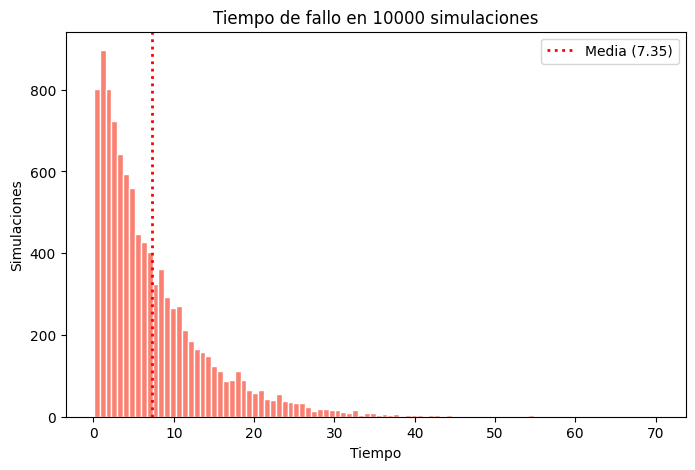

In [5]:
# Punto 3
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(datos, bins="auto", edgecolor="white", color="salmon")

plt.axvline(x=media, color="red", linestyle='dotted',
            linewidth=2, label=f'Media ({media:.2f})')

plt.title(f"Tiempo de fallo en {N_SIM} simulaciones")
plt.xlabel("Tiempo")
plt.ylabel("Simulaciones")
plt.legend()
plt.show()

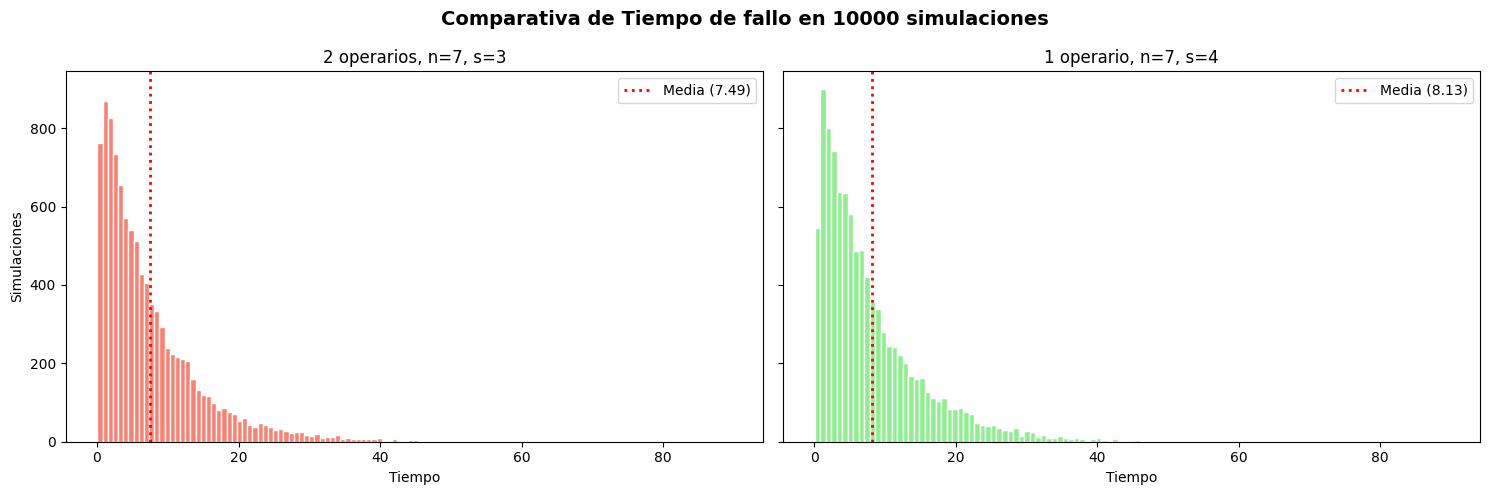

In [6]:
# Punto 4 - Comparación entre añadir 1 operario o añadir 1 maquina de repuesto mas
import matplotlib.pyplot as plt


def generar_t_fallo_1_operario_1_maq_mas():
    return reparacion_1_operario(
        7, 4, t_funcionamiento, t_reparacion_operario_1
    )


N_SIM = 10_000

# Datos para 2 operarios
datos_2_op = [generar_t_fallo_2_operarios() for _ in range(N_SIM)]
media_2_op = np.mean(datos_2_op)

# Datos para 1 maquina de mas
datos_1_op = [generar_t_fallo_1_operario_1_maq_mas() for _ in range(N_SIM)]
media_1_op = np.mean(datos_1_op)

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)

# Gráfica de 2 operarios
axes[0].hist(datos_2_op, bins="auto", edgecolor="white", color="salmon")
axes[0].axvline(x=media_2_op, color="red",
                linestyle='dotted', linewidth=2, label=f'Media ({media_2_op:.2f})')
axes[0].set_title("2 operarios, n=7, s=3")
axes[0].set_ylabel("Simulaciones")
axes[0].set_xlabel("Tiempo")
axes[0].legend()

# Gráfica de 1 operario y 1 maquina de repuesto mas
axes[1].hist(datos_1_op, bins="auto",
             edgecolor="white", color="lightgreen")
axes[1].axvline(x=media_1_op, color="red",
                linestyle='dotted', linewidth=2, label=f'Media ({media_1_op:.2f})')
axes[1].set_title("1 operario, n=7, s=4")
axes[1].set_xlabel("Tiempo")
axes[1].legend()


fig.suptitle(
    f"Comparativa de Tiempo de fallo en {N_SIM} simulaciones", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Punto 4 - Prueba de Bondad de Ajuste
import scipy.stats as st

def test_ba_weibull_and_gamma(muestra: list[float]):
    # ---------- Prueba contra distribución Weibull
    # Se estiman los parámetros de la Weibull según la muestra
    par_weibull = st.exponweib.fit(muestra)

    # Realiza el test Kolmogorov-Smirnov
    d_weibull, p_valor_weibull = st.kstest(muestra, st.exponweib.cdf, args=par_weibull)

    # ---------- Prueba contra distribución Gamma
    # Se estiman los parámetros de la Gamma según la muestra
    par_gamma = st.gamma.fit(muestra)

    # Realiza el test Kolmogorov-Smirnov
    d_gamma, p_valor_gamma = st.kstest(muestra, st.gamma.cdf, args=par_gamma)

    return d_weibull, p_valor_weibull, d_gamma, p_valor_gamma


print("Prueba de bondad de Ajuste para el caso 'Se añade 1 operario'")
d_weibull, p_valor_weibull, d_gamma, p_valor_gamma = test_ba_weibull_and_gamma(datos_2_op)

print(f"Ajuste a distribución Weibull:")
print(f"- Estadístico D : {d_weibull:.4f}")
print(f"- P-valor       : {p_valor_weibull:.4e}")

print()
print(f"Ajuste a distribución Gamma:")
print(f"- Estadístico D : {d_gamma:.4f}")
print(f"- P-valor       : {p_valor_gamma:.4e}")


print()
print("Prueba de bondad de Ajuste para el caso 'Se añade 1 caja registradora'")
d_weibull, p_valor_weibull, d_gamma, p_valor_gamma = test_ba_weibull_and_gamma(datos_1_op)

print(f"Ajuste a distribución Weibull:")
print(f"- Estadístico D : {d_weibull:.4f}")
print(f"- P-valor       : {p_valor_weibull:.4e}")

print()
print(f"Ajuste a distribución Gamma:")
print(f"- Estadístico D : {d_gamma:.4f}")
print(f"- P-valor       : {p_valor_gamma:.4e}")

Prueba de bondad de Ajuste para el caso 'Se añade 1 operario'
Ajuste a distribución Weibull:
- Estadístico D : 0.0096
- P-valor       : 3.1640e-01

Ajuste a distribución Gamma:
- Estadístico D : 0.0167
- P-valor       : 7.5961e-03

Prueba de bondad de Ajuste para el caso 'Se añade 1 caja registradora'
Ajuste a distribución Weibull:
- Estadístico D : 0.0134
- P-valor       : 5.4839e-02

Ajuste a distribución Gamma:
- Estadístico D : 0.0210
- P-valor       : 2.7999e-04
